## Análisis interactivo de partidas SGF y mapas posicionales

Este cuaderno es la entrada operativa para cargar partidas SGF, reproducirlas con el motor de reglas del proyecto y visualizar el tablero junto con mapas posicionales spin-1.

La línea actual del proyecto no interpreta estos mapas como una solución global del Go. Los usamos como lecturas locales del tablero: influencia, libertades, conexión, contacto y estructura sobre vecindades Manhattan.

**Convención spin-1:** negro $=-1$, blanco $=+1$, vacío $=0$.

**Estado de implementación en este cuaderno:**

- `cubic` es el mapa cúbico spin-1: $E_{\text{cub}}(s_0,s_1)=s_0+2s_1-s_0s_1^2-s_0^2s_1$.
- `quadratic` es el mapa cuadrático tipo Ising/Atomic-Go: $E_{\text{quad}}(s_0,s_1)=-J s_0s_1$.
- **Agregación por capas:** cada capa Manhattan **suma directamente** sus vecinos válidos y se pondera con $w_R = 1/R$ — no se promedia. Consecuencia deliberada: los puntos con menos vecinos reciben menos señal, es decir **esquina < orilla < centro** (una piedra sola con todas sus libertades marca $\pm 4$ en el centro, $\pm 3$ en la orilla, $\pm 2$ en la esquina), que es la intuición correcta del Go.
- **Sufijo de jugada hipotética** `-hipB` / `-hipW`: evalúa cada punto vacío como si ese color jugara ahí (p. ej. `m1-cubic-hipB`). Sobre las piedras existentes el mapa no cambia. (El sufijo `-raw` de versiones anteriores se acepta como alias sin efecto: la suma directa es ahora el único modo.)
- `classical` queda como alias histórico de `cubic`; `quantum` queda como backend heredado para comparación (no soporta sufijos).

Las exportaciones pesadas y GIFs están desactivados por defecto para mantener el notebook liviano.


## Lectura local: tabla y grafo de interacción

Antes de recorrer una partida completa, conviene fijar la lectura de una interacción centro-vecino $(s_0,s_1)$. Las dos láminas siguientes resumen el punto didáctico central: los mismos pares locales producen lecturas distintas según usemos el mapa cúbico o el mapa cuadrático.

<p align="center">
  <img src="../data/assets/comparacion_tabla_m1.svg" alt="Tabla de interacción comparada: mapa cúbico M1 vs mapa cuadrático" width="920"/>
</p>

<p align="center">
  <img src="../data/assets/comparacion_grafo_m1.svg" alt="Grafo de interacción comparado: mapa cúbico M1 vs mapa cuadrático" width="920"/>
</p>

Claves de lectura:

- En el mapa `cubic`, el signo expresa orientación de color: negativo hacia negro, positivo hacia blanco.
- En el mapa `quadratic`, el signo expresa estructura: valores negativos favorecen conexión; valores positivos marcan contacto o conflicto.
- Los vacíos separan claramente ambos mapas: `cubic` ilumina influencia en puntos vacíos, mientras que `quadratic` necesita una piedra real o hipotética para producir señal.
- Las pestañas `hip. Negro` / `hip. Blanco` responden a "¿qué pasa si este color juega aquí?": en el cuadrático hipotético, los vacíos con valor negativo conectan con piedras propias; en el cúbico hipotético se combinan libertad local y balance de color vecino (la escala sigue siendo blanco-positivo).


In [1]:
# Imports y rutas

import sys
import importlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from bokeh.io import output_notebook

# Detectar la raíz del proyecto, tanto si el notebook corre desde /notebooks
# como si corre desde la raíz del repositorio.
root = Path.cwd()
if not (root / 'src').exists():
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import src.go_isings_models as gim
import src.go_energy_viz as gev
import src.go_export_utils as geu
import src.go_visualization as gv

importlib.reload(gim)
importlib.reload(gev)
importlib.reload(geu)
importlib.reload(gv)

from src.go_game_engine import GoBoard, SGFParser
from src.go_visualization import GoBoardVisualizer, GameNavigator

output_notebook()
print(f'Raíz del proyecto: {root}')
print('Imports listos')


Loading BokehJS ...

Raíz del proyecto: c:\Users\ometi\Documents\IA\Github\Ising-go\Proyect-Quantum-Go
Imports listos


## Flujo del cuaderno

1. Configurar el archivo SGF y los mapas a visualizar.
2. Cargar la partida, reproducirla y validar reglas básicas.
3. Mostrar la posición final con libertades o números de jugada.
4. Navegar la partida con pestañas interactivas.
5. Ejecutar verificaciones o exportaciones solo cuando se activen explícitamente.


In [ ]:
# Configuración principal

SGF_FILE = '3a3d-gokifu-20210609-Peng_Liyao-Xia_Chenkun.sgf'
sgf_path = root / 'data' / 'sgf partidas' / SGF_FILE

# Visualización de la posición final: 'libertades', 'movimientos' o 'ambos'.
MOSTRAR = 'libertades'
assert MOSTRAR in {'libertades', 'movimientos', 'ambos'}

# Mapas posicionales disponibles en la API actual.
# Métodos principales: 'cubic' y 'quadratic'. Alias heredados: 'classical' y 'quantum'.
# Sufijo de jugada hipotética: '-hipB' / '-hipW' (p. ej. 'cubic-hipB').
# MAP_MANHATTAN acepta cualquier radio >= 1: los mapas clásicos están vectorizados
# por convoluciones (19x19 con R=9 tarda ~3 ms). El backend 'quantum' queda acotado
# a R<=2 (el kernel usa 1+2R(R+1) qubits: R=3 ya son 25).
MAP_MANHATTAN = 1
MAP_METHOD = 'cubic'
assert isinstance(MAP_MANHATTAN, int) and MAP_MANHATTAN >= 1
gim.parse_map_method(MAP_METHOD)  # valida el método; acepta claves compuestas como 'cubic-hipB'

# Pestañas del navegador. Se renderizan bajo demanda al abrir cada pestaña.
# La clave es paramétrica: 'm<RADIO>-<método>[-hipB|-hipW]', con cualquier radio.
# Ejemplos válidos: 'm3-quadratic-hipW', 'm5-cubic-hipB', 'm9-cubic'.
ENERGY_TABS = [
    'm1-cubic', 'm2-cubic',
    'm1-quadratic', 'm2-quadratic',
    'm1-cubic-hipB', 'm1-cubic-hipW',
    'm2-cubic-hipB', 'm2-cubic-hipW',
    'm1-quadratic-hipB', 'm1-quadratic-hipW',
]
ENERGY_BACKEND = 'bokeh'   # 'bokeh' o 'mpl'
NAV_FIGSIZE = (6.0, 6.0)
NAV_WIDTH = '100%'

# Exportaciones. Mantener apagado por defecto para evitar outputs pesados.
RUN_EXPORTS = False
RUN_GIFS = False
RUN_PARITY_CHECK = False
RUN_BOARD_EDITOR = False

# Parámetros usados si RUN_EXPORTS o RUN_GIFS se activan.
MOVE_INDEX = 150
EXPORT_FINAL = True
SHOW_LIBERTIES = True
DPI = 300
MAP_CMAP = 'coolwarm'
MAP_ALPHA = 0.45
MAP_SYMMETRIC = True
OUTPUT_DIR = root / 'results'

print('Archivo SGF:', sgf_path)
print(f'Mapa por defecto: M{MAP_MANHATTAN} | {MAP_METHOD}')
print(f'Pestañas: {ENERGY_TABS}')
print(f'Exportaciones activas: {RUN_EXPORTS}; GIFs activos: {RUN_GIFS}')



INFORMACIÓN DE LA PARTIDA
Negro:    Peng Liyao (7p)
Blanco:   Xia Chenkun (7p)
Fecha:    2021-06-09
Tamaño:   19x19
Komi:     7.5
Resultado:B+R
Ganador:  Negro
Movimientos: 175
Partida reproducida correctamente
Capturas finales: Negro capturó 4 | Blanco capturó 0


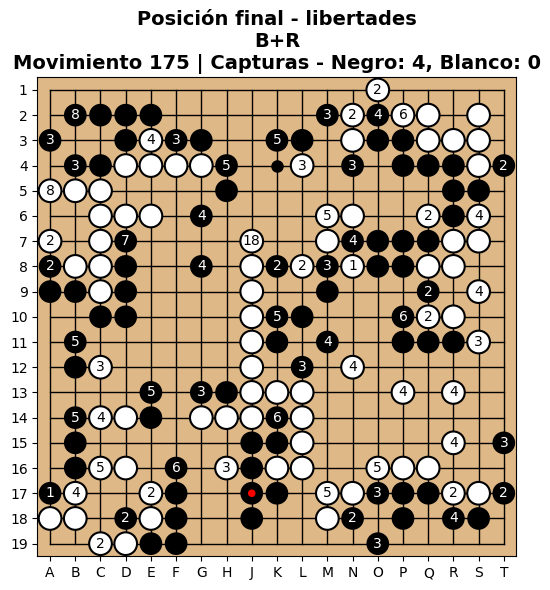

In [3]:
# Cargar, reproducir y analizar la partida SGF

if not sgf_path.exists():
    raise FileNotFoundError(f'No se encontró el SGF:\n{sgf_path}')

parser = SGFParser()
try:
    moves, game_info = parser.parse_file(sgf_path)
except ImportError as exc:
    raise ImportError(
        'No se pudo cargar el parser SGF. Instala las dependencias con `pip install -r requirements.txt` '
        'o instala `sgfmill`, y vuelve a ejecutar el cuaderno.'
    ) from exc

print('\n' + '=' * 70)
print('INFORMACIÓN DE LA PARTIDA')
print('=' * 70)
print(f'Negro:    {game_info.black_player} ({game_info.black_rank})')
print(f'Blanco:   {game_info.white_player} ({game_info.white_rank})')
print(f'Fecha:    {game_info.date}')
print(f'Tamaño:   {game_info.board_size}x{game_info.board_size}')
print(f'Komi:     {game_info.komi}')
print(f'Resultado:{game_info.result}')
if game_info.winner:
    winner_name = 'Negro' if game_info.winner == 'B' else 'Blanco'
    print(f'Ganador:  {winner_name}')
print(f'Movimientos: {len(moves)}')
print('=' * 70)

board = GoBoard(size=game_info.board_size)
results = board.replay_moves(moves)

illegal_moves = [r for r in results if not r.is_legal]
if illegal_moves:
    print(f'Se detectaron {len(illegal_moves)} movimientos ilegales')
else:
    print('Partida reproducida correctamente')

captures = board.get_captures()
print(f"Capturas finales: Negro capturó {captures['B']} | Blanco capturó {captures['W']}")

vis = GoBoardVisualizer(board)

if MOSTRAR in {'libertades', 'ambos'}:
    fig, ax = vis.plot_matplotlib(
        title=f'Posición final - libertades\n{game_info.result}',
        show_liberties=True,
        show_move_numbers=False,
        figsize=(6, 6),
    )
    plt.show()

if MOSTRAR in {'movimientos', 'ambos'}:
    fig, ax = vis.plot_matplotlib(
        title=f'Posición final - números de jugada\n{game_info.result}',
        show_liberties=False,
        show_move_numbers=True,
        figsize=(8, 8),
    )
    plt.show()


In [ ]:
# Navegador interactivo de partida

from ipywidgets import Layout

nav = GameNavigator(moves, board_size=game_info.board_size)
ui = nav.create_view(
    figsize=NAV_FIGSIZE,
    include_energy_tabs=True,
    energy_backend=ENERGY_BACKEND,
    energy_tabs=ENERGY_TABS,
)

try:
    ui.children[1].layout = Layout(width=NAV_WIDTH)
except Exception:
    pass

display(ui)


Loading BokehJS ...

In [5]:
# Verificación opcional heredada: paridad quantum/classical del modelo anterior
# Puede tardar en tableros 19x19; por eso RUN_PARITY_CHECK está apagado por defecto.

if not RUN_PARITY_CHECK:
    print('RUN_PARITY_CHECK=False. Actívalo en la celda de configuración para ejecutar esta comparación.')
else:
    from src.go_isings_models import quantum_classical_parity

    board_np = np.array(board.board, dtype=str)
    parity = quantum_classical_parity(board_np, manhattan_distance=MAP_MANHATTAN)

    print(f"M{MAP_MANHATTAN} | max_abs_diff  = {parity['max_abs_diff']:.6g}")
    print(f"M{MAP_MANHATTAN} | mean_abs_diff = {parity['mean_abs_diff']:.6g}")
    print(f"All close: {parity['allclose']}")


RUN_PARITY_CHECK=False. Actívalo en la celda de configuración para ejecutar esta comparación.


In [6]:
# Exportación opcional de tablero y mapa posicional

if not RUN_EXPORTS:
    print('RUN_EXPORTS=False. Actívalo en la celda de configuración para exportar PNG.')
else:
    from src.go_visualization import export_position_image
    from src.go_export_utils import export_positional_map_image

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    sgf_stem = Path(sgf_path).stem
    tipo = 'libertades' if SHOW_LIBERTIES else 'jugadas'

    def board_at(move_index: int):
        b = GoBoard(size=game_info.board_size)
        if move_index > 0:
            b.replay_moves(moves[:move_index])
        return b

    print('\n' + '=' * 70)
    print('EXPORTACIÓN DE POSICIONES')
    print('=' * 70)
    print(f'Jugada a exportar: {MOVE_INDEX} (rango 0-{len(moves)})')
    print(f'Mapa: M{MAP_MANHATTAN} | {MAP_METHOD}')
    print(f'Carpeta: {OUTPUT_DIR.resolve()}')

    if 0 <= MOVE_INDEX <= len(moves):
        b_k = board_at(MOVE_INDEX)

        export_position_image(
            b_k,
            filename=f'{sgf_stem}_m{MOVE_INDEX}_{tipo}.png',
            show_liberties=SHOW_LIBERTIES,
            show_move_numbers=not SHOW_LIBERTIES,
            dpi=DPI,
            output_dir=str(OUTPUT_DIR),
        )

        export_positional_map_image(
            b_k,
            filename=f'{sgf_stem}_m{MOVE_INDEX}_map_m{MAP_MANHATTAN}_{MAP_METHOD}.png',
            manhattan_distance=MAP_MANHATTAN,
            method=MAP_METHOD,
            dpi=DPI,
            output_dir=str(OUTPUT_DIR),
            figsize=(12, 12),
            cmap=MAP_CMAP,
            alpha=MAP_ALPHA,
            symmetric=MAP_SYMMETRIC,
        )
    else:
        print(f'Movimiento fuera de rango: {MOVE_INDEX}')

    if EXPORT_FINAL:
        export_position_image(
            board,
            filename=f'{sgf_stem}_final_{tipo}.png',
            show_liberties=SHOW_LIBERTIES,
            show_move_numbers=not SHOW_LIBERTIES,
            dpi=DPI,
            output_dir=str(OUTPUT_DIR),
        )

        export_positional_map_image(
            board,
            filename=f'{sgf_stem}_final_map_m{MAP_MANHATTAN}_{MAP_METHOD}.png',
            manhattan_distance=MAP_MANHATTAN,
            method=MAP_METHOD,
            dpi=DPI,
            output_dir=str(OUTPUT_DIR),
            figsize=(12, 12),
            cmap=MAP_CMAP,
            alpha=MAP_ALPHA,
            symmetric=MAP_SYMMETRIC,
        )

    print('Exportación completada')


RUN_EXPORTS=False. Actívalo en la celda de configuración para exportar PNG.


In [7]:
# GIFs opcionales: tablero y tablero + mapa posicional
# Mantener apagado por defecto porque genera archivos grandes y tarda en partidas largas.

if not RUN_GIFS:
    print('RUN_GIFS=False. Actívalo en la celda de configuración para generar GIFs.')
else:
    from src.go_visualization import create_move_animation
    from src.go_export_utils import create_move_animation_map

    MAKE_BOARD_GIF = True
    MAKE_MAP_GIF = True
    INTERVAL_MS = 800
    MAX_FRAMES = None  # usa un entero, por ejemplo 200, para recortar

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    sgf_stem = Path(sgf_path).stem

    if MAKE_BOARD_GIF:
        gif_name = f'{sgf_stem}_board.gif'
        create_move_animation(
            nav,
            output_file=gif_name,
            interval=INTERVAL_MS,
            output_dir=str(OUTPUT_DIR),
            max_frames=MAX_FRAMES,
        )
        display(Image(filename=str(OUTPUT_DIR / gif_name)))

    if MAKE_MAP_GIF:
        gif_name_map = f'{sgf_stem}_map_m{MAP_MANHATTAN}_{MAP_METHOD}.gif'
        create_move_animation_map(
            nav,
            output_file=gif_name_map,
            interval=INTERVAL_MS,
            output_dir=str(OUTPUT_DIR),
            max_frames=MAX_FRAMES,
            figsize=(10, 10),
            map_manhattan=MAP_MANHATTAN,
            map_method=MAP_METHOD,
            map_cmap=MAP_CMAP,
            map_alpha=MAP_ALPHA,
            symmetric_map=MAP_SYMMETRIC,
        )
        display(Image(filename=str(OUTPUT_DIR / gif_name_map)))

    print(f'GIFs guardados en: {OUTPUT_DIR.resolve()}')


RUN_GIFS=False. Actívalo en la celda de configuración para generar GIFs.


In [8]:
# Editor manual opcional de tableros

if not RUN_BOARD_EDITOR:
    print('RUN_BOARD_EDITOR=False. Actívalo en la celda de configuración para abrir el editor manual.')
else:
    from src.go_visualization import BoardEditor

    editor = BoardEditor(
        board_size=9,
        figsize=(5, 5),
        energy_backend=ENERGY_BACKEND,
        energy_tabs=ENERGY_TABS,
        show_log=False,
    )
    display(editor.view())


RUN_BOARD_EDITOR=False. Actívalo en la celda de configuración para abrir el editor manual.
